# Time-frequency analysis on CPP channels

这个 notebook 对 `CPP_CHANNELS` 做 Morlet 小波时频分析。
输出包括：
- 所有 epoch 合并后的总体时频图
- 四个 `cue_dimensionality` 条件各自的时频图
- 简单的频段均值总结，帮助解释结果

In [1]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import logging
from collections import defaultdict


In [2]:
# == Configuration ==
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR if (CURRENT_DIR / '02_Script').exists() else CURRENT_DIR.parent

if (PROJECT_DIR / 'data' / 'preprocess').exists():
    PATH_PREPROCESS_DATA_BIDS = PROJECT_DIR / 'data' / 'preprocess'
else:
    PATH_PREPROCESS_DATA_BIDS = PROJECT_DIR / '01_Data' / 'preprocess'

SUBJECT_IDS = [f'sub-{i}' for i in [
    1117, 1118, 1120,
    #1124, 1126, 1131, 1132, 1135, 1136,
    #1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    #1182, 1215, 1216, 1219, 1223, 1227, 1233,
    #1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    #1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281
]]

ERP_TMIN, ERP_TMAX = -0.5, 2.0
BASELINE_TMIN, BASELINE_TMAX = -0.25, 0.0
CPP_CHANNELS = ['POz', 'CPz', 'CP2', 'CP1', 'P3', 'Pz', 'P2', 'PO3', 'PO4']
CONDITIONS = [1, 2, 3, 4]

FREQS = np.arange(2, 31, 2)
N_CYCLES = FREQS / 2
BASELINE_MODE = 'logratio'


In [3]:
beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

all_subject_tfr = []
condition_tfr = defaultdict(list)
included_subjects = []
times = None

for sub_id in SUBJECT_IDS:
    if sub_id not in beh_by_sub or sub_id not in eeg_by_sub:
        logger.warning(f'{sub_id}: missing EEG or behavior file, skipping')
        continue

    logger.info(f'Processing subject: {sub_id}')
    data_behavior = pd.read_csv(beh_by_sub[sub_id])

    raw = mne.io.read_raw_brainvision(eeg_by_sub[sub_id], preload=True, verbose='ERROR')
    events, _ = mne.events_from_annotations(raw, verbose='ERROR')

    raw.set_channel_types({
        'VEOG': 'eog',
        'HEOGL': 'eog',
        'HEOGR': 'eog',
        'ECG': 'ecg',
    })
    raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')

    stim_events = events[events[:, 2] == 8]
    assert len(stim_events) == len(data_behavior), f'{sub_id}: events and behavior rows differ'

    epochs_full = mne.Epochs(
        raw,
        events=stim_events,
        event_id={'Stimulus/S  8': 8},
        tmin=ERP_TMIN,
        tmax=ERP_TMAX,
        baseline=None,
        reject={'eeg': 200e-5},
        metadata=data_behavior,
        preload=True,
        event_repeated='drop',
        verbose='ERROR',
    )

    available_cpp_channels = [ch for ch in CPP_CHANNELS if ch in epochs_full.ch_names]
    if len(available_cpp_channels) == 0:
        logger.warning(f'{sub_id}: no CPP channels available, skipping')
        continue

    power_all = epochs_full.compute_tfr(
        method='morlet',
        freqs=FREQS,
        n_cycles=N_CYCLES,
        picks=available_cpp_channels,
        average=True,
        return_itc=False,
        verbose='ERROR',
    )
    power_all.apply_baseline((BASELINE_TMIN, BASELINE_TMAX), mode=BASELINE_MODE)

    if times is None:
        times = power_all.times.copy()

    all_subject_tfr.append(power_all.data.mean(axis=0))

    for con in CONDITIONS:
        epochs_condition = epochs_full[f'cue_dimensionality == {con}']
        if len(epochs_condition) == 0:
            logger.warning(f'{sub_id}: no trials for cue_dimensionality == {con}')
            continue

        power_condition = epochs_condition.compute_tfr(
            method='morlet',
            freqs=FREQS,
            n_cycles=N_CYCLES,
            picks=available_cpp_channels,
            average=True,
            return_itc=False,
            verbose='ERROR',
        )
        power_condition.apply_baseline((BASELINE_TMIN, BASELINE_TMAX), mode=BASELINE_MODE)
        condition_tfr[con].append(power_condition.data.mean(axis=0))

    included_subjects.append(sub_id)

overall_tfr = np.mean(np.stack(all_subject_tfr, axis=0), axis=0)
condition_avg_tfr = {con: np.mean(np.stack(condition_tfr[con], axis=0), axis=0) for con in CONDITIONS}

print(f'Included subjects: {included_subjects}')
print(f'Overall TFR shape: {overall_tfr.shape}')
for con in CONDITIONS:
    print(f'Condition {con} TFR shape: {condition_avg_tfr[con].shape}')


2026-06-13 13:22:48,925 - INFO - Processing subject: sub-1117
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_57811/598441750.py:28: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


2026-06-13 13:22:52,431 - INFO - Processing subject: sub-1118
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_57811/598441750.py:28: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


2026-06-13 13:22:54,580 - INFO - Processing subject: sub-1120
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_57811/598441750.py:28: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['A1']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False, on_missing='ignore')


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Included subjects: ['sub-1117', 'sub-1118', 'sub-1120']
Overall TFR shape: (15, 641)
Condition 1 TFR shape: (15, 641)
Condition 2 TFR shape: (15, 641)
Condition 3 TFR shape: (15, 641)
Condition 4 TFR shape: (15, 641)


In [4]:
post_mask = times >= 0
post_time_idx = np.where(post_mask)[0]
overall_post = overall_tfr[:, post_time_idx]

max_idx = np.unravel_index(np.argmax(overall_post), overall_post.shape)
min_idx = np.unravel_index(np.argmin(overall_post), overall_post.shape)

max_freq = FREQS[max_idx[0]]
max_time = times[post_time_idx][max_idx[1]]
max_value = overall_post[max_idx]

min_freq = FREQS[min_idx[0]]
min_time = times[post_time_idx][min_idx[1]]
min_value = overall_post[min_idx]

band_definitions = {
    'theta_4_8': (4, 8),
    'alpha_8_12': (8, 12),
    'beta_14_24': (14, 24),
}

time_window_mask = (times >= 0.2) & (times <= 1.0)
band_rows = []

for band_name, (fmin, fmax) in band_definitions.items():
    freq_mask = (FREQS >= fmin) & (FREQS <= fmax)
    band_rows.append({
        'band': band_name,
        'overall_mean_logratio': float(overall_tfr[np.ix_(freq_mask, time_window_mask)].mean()),
        'condition_1': float(condition_avg_tfr[1][np.ix_(freq_mask, time_window_mask)].mean()),
        'condition_2': float(condition_avg_tfr[2][np.ix_(freq_mask, time_window_mask)].mean()),
        'condition_3': float(condition_avg_tfr[3][np.ix_(freq_mask, time_window_mask)].mean()),
        'condition_4': float(condition_avg_tfr[4][np.ix_(freq_mask, time_window_mask)].mean()),
    })

band_summary_df = pd.DataFrame(band_rows)
print(f'Strongest post-stimulus increase: {max_freq} Hz at {max_time:.3f} s, value = {max_value:.3f}')
print(f'Strongest post-stimulus decrease: {min_freq} Hz at {min_time:.3f} s, value = {min_value:.3f}')
display(band_summary_df)


Strongest post-stimulus increase: 2 Hz at 0.230 s, value = 0.350
Strongest post-stimulus decrease: 10 Hz at 2.000 s, value = -1.040


,band,overall_mean_logratio,condition_1,condition_2,condition_3,condition_4
0,theta_4_8,-0.196229,-0.209085,-0.236724,-0.174366,-0.172898
1,alpha_8_12,-0.487943,-0.515475,-0.521115,-0.452581,-0.477519
2,beta_14_24,-0.219082,-0.237132,-0.244589,-0.201098,-0.203780


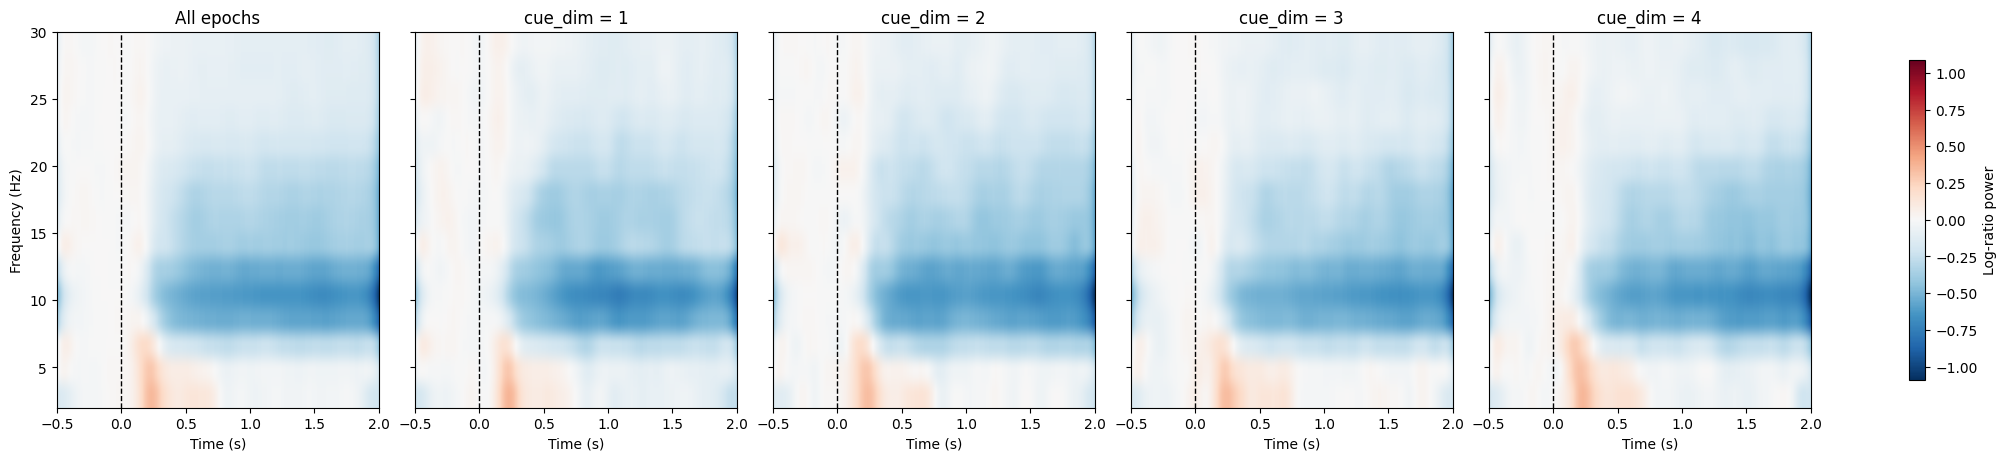

In [5]:
all_maps = [overall_tfr] + [condition_avg_tfr[con] for con in CONDITIONS]
vlim = np.max(np.abs(np.concatenate([m[np.newaxis, ...] for m in all_maps], axis=0)))

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharey=True, constrained_layout=True)

im = axes[0].imshow(
    overall_tfr,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], FREQS[0], FREQS[-1]],
    cmap='RdBu_r',
    vmin=-vlim,
    vmax=vlim,
)
axes[0].set_title('All epochs')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

for plot_idx, con in enumerate(CONDITIONS, start=1):
    axes[plot_idx].imshow(
        condition_avg_tfr[con],
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], FREQS[0], FREQS[-1]],
        cmap='RdBu_r',
        vmin=-vlim,
        vmax=vlim,
    )
    axes[plot_idx].set_title(f'cue_dim = {con}')
    axes[plot_idx].set_xlabel('Time (s)')
    axes[plot_idx].axvline(0, color='black', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, shrink=0.85, label='Log-ratio power')
plt.show()
